# V4 OMR Pipeline - Step-by-step Visualization
This notebook mirrors V4.py and visualizes each stage of the pipeline with explanations.

## 1) Setup and helpers
We load libraries, define paths, and add helper utilities used across the notebook.
The helpers keep plotting consistent and replicate the grid logic from V4.py.
If you change image paths or datasets, update them here first.

In [709]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imutils
from collections import defaultdict
IDX = 1
IMG_REF_PATH  = '../synthetic/ref2.png'
PROCESSED_DIR = '../synth100/processed_data'
LABELS_CSV    = '../synth100/labels.csv'

def show(title, img, cmap=None, figsize=(9, 7)):
    plt.figure(figsize=figsize)
    if cmap is None and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def sort_key(s):
    p = re.match(r'(\d+)([A-Z])', s)
    return int(p.group(1)), p.group(2)

def _group_medians(values, groups):
    if len(values) == 0:
        return []
    if len(values) < groups:
        return list(np.linspace(float(np.min(values)), float(np.max(values)), groups))
    splits = np.array_split(np.sort(values), groups)
    return [float(np.median(s)) for s in splits]

def build_grid(cnts, rows=15, cols=16):
    if not cnts:
        return []
    centers, widths, heights = [], [], []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        centers.append((x + w / 2.0, y + h / 2.0, x, y, w, h))
        widths.append(w)
        heights.append(h)
    col_centers = _group_medians([c[0] for c in centers], cols)
    row_centers = _group_medians([c[1] for c in centers], rows)
    median_w = int(np.median(widths))
    median_h = int(np.median(heights))
    grid = {}
    for cx, cy, x, y, w, h in centers:
        ri = int(np.argmin([abs(cy - r) for r in row_centers]))
        ci = int(np.argmin([abs(cx - c) for c in col_centers]))
        dist = abs(cy - row_centers[ri]) + abs(cx - col_centers[ci])
        key = (ri, ci)
        if key not in grid or dist < grid[key]['dist']:
            grid[key] = {'x': x, 'y': y, 'w': w, 'h': h, 'dist': dist}
    boxes = []
    for r in range(rows):
        for c in range(cols):
            if (r, c) in grid:
                b = grid[(r, c)]
                boxes.append({'x': int(b['x']), 'y': int(b['y']), 'w': int(b['w']), 'h': int(b['h'])})
            else:
                boxes.append({'x': int(col_centers[c] - median_w / 2),
                              'y': int(row_centers[r] - median_h / 2),
                              'w': median_w, 'h': median_h})
    return boxes

## 2) Load reference and sample
We load the reference template and choose a sample from the processed set.
Seeing both images up front helps confirm expected resolution and rotation.
If this fails, the rest of the pipeline will not be meaningful.

Sample: ../synth100/processed_data\synthetic_sample_2.png


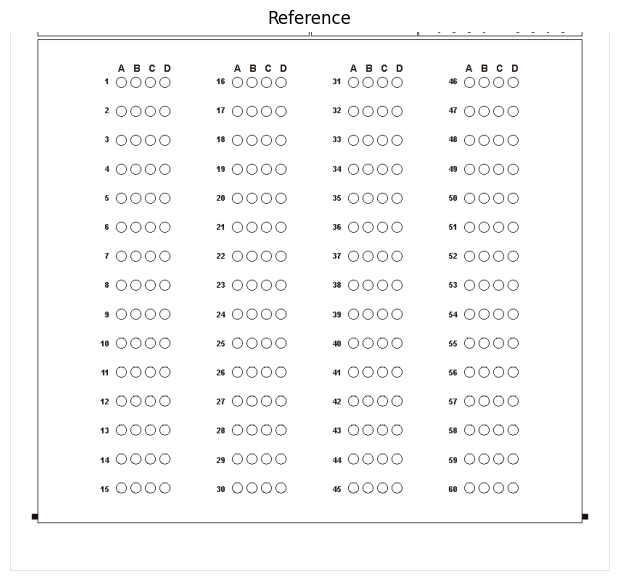

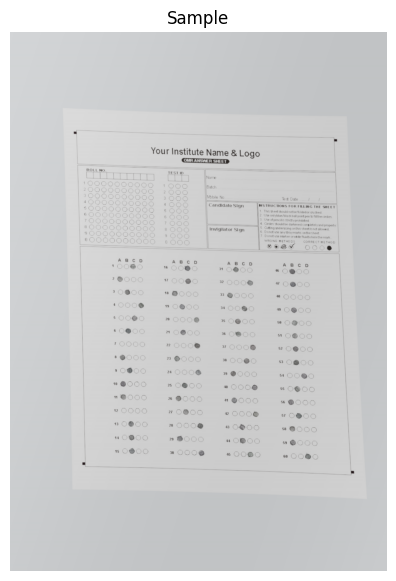

In [710]:
img_ref = cv2.imread(IMG_REF_PATH)
assert img_ref is not None, f'Reference image not found: {IMG_REF_PATH}'

files = [f for f in os.listdir(PROCESSED_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
def sort_files(x):
    m = re.match(r'synthetic_sample_(\d+)\.png', x)
    return int(m.group(1)) if m else x
files.sort(key=sort_files)

sample_path = os.path.join(PROCESSED_DIR, files[IDX])
# sample_path = "../synthetic\\processed_data\\synthetic_sample_7.png"
img_sample = cv2.imread(sample_path)
print('Sample:', sample_path)
show('Reference', img_ref)
show('Sample', img_sample)

## 3) SIFT keypoints and matches
SIFT features provide rotation and scale-invariant matches between the reference and sample.
We visualize keypoints to ensure enough texture exists and draw the first set of good matches.
Poor or sparse matches usually indicate a low-quality scan or heavy blur.

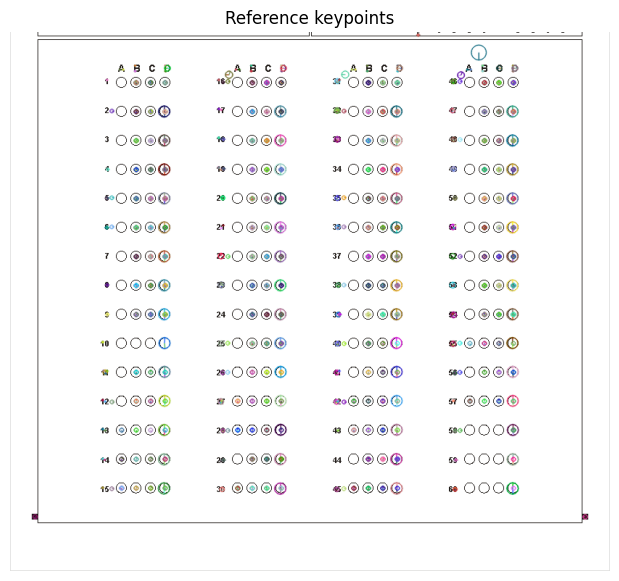

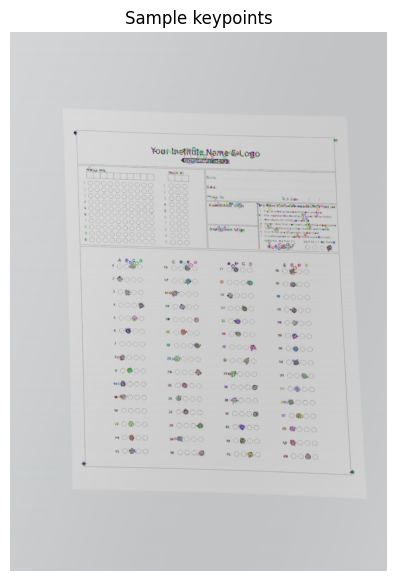

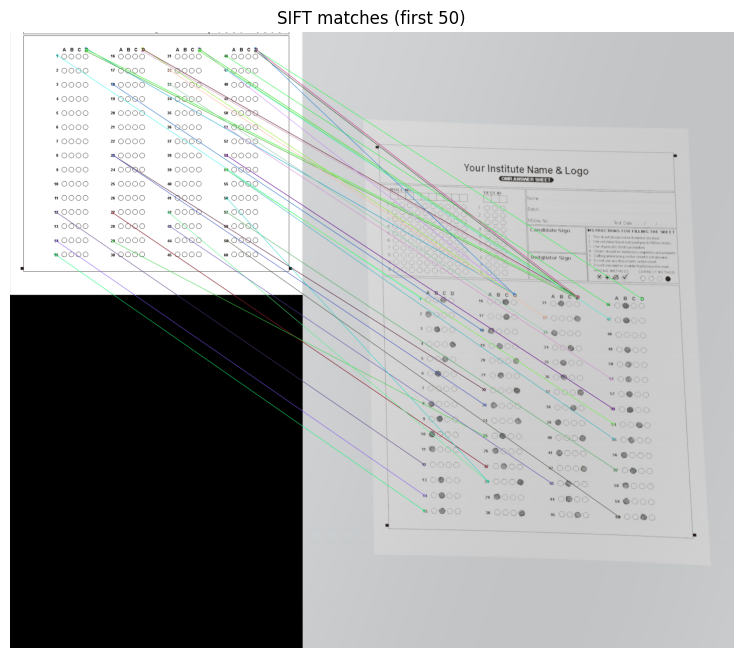

In [711]:
gray_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2GRAY)
gray_sample = cv2.cvtColor(img_sample, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_ref, None)
kp2, des2 = sift.detectAndCompute(gray_sample, None)

ref_kp = cv2.drawKeypoints(img_ref, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
sample_kp = cv2.drawKeypoints(img_sample, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
show('Reference keypoints', ref_kp)
show('Sample keypoints', sample_kp)

if des1 is None or des2 is None:
    raise RuntimeError('No descriptors found in one of the images.')

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
knn_matches = bf.knnMatch(des1, des2, k=2)
good = []
for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)
match_vis = cv2.drawMatches(img_ref, kp1, img_sample, kp2, good[:50], None, flags=2)
show('SIFT matches (first 50)', match_vis, figsize=(12, 8))

## 4) Homography and registration
Using the matched keypoints, we estimate a homography to align the sample to the reference.
The goal is pixel-level alignment so that the fixed bubble grid can be reused.
If the result looks skewed, later grid mapping will be unreliable.

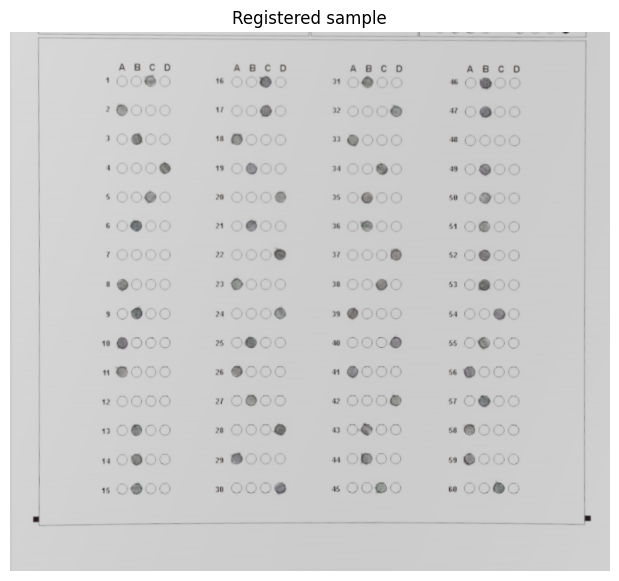

In [712]:
points1 = np.array([kp1[m.queryIdx].pt for m in good], dtype=np.float32)
points2 = np.array([kp2[m.trainIdx].pt for m in good], dtype=np.float32)
h_matrix, _ = cv2.findHomography(points2, points1, cv2.RANSAC, 5.0)
h, w = img_ref.shape[:2]
registered = cv2.warpPerspective(img_sample, h_matrix, (w, h))
show('Registered sample', registered)

## 5) Shadow removal
We estimate the background illumination using dilation and median blur.
Subtracting this background normalizes uneven lighting and reduces paper shadows.
The output should show bubbles with clearer contrast.

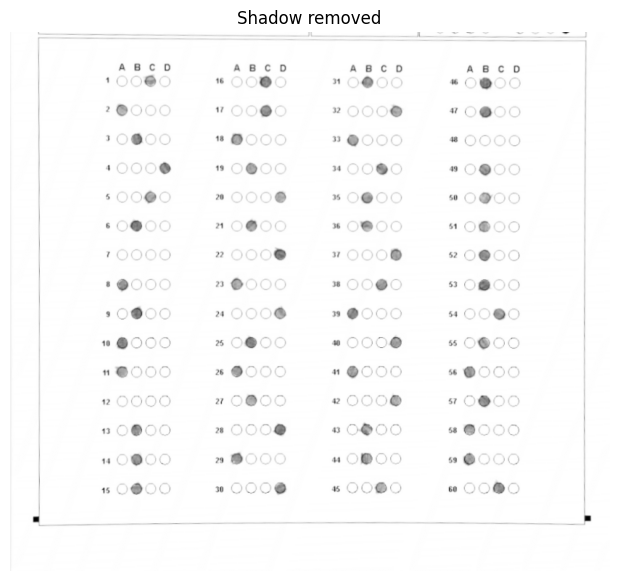

In [713]:
img_gray = cv2.cvtColor(registered, cv2.COLOR_BGR2GRAY)
se = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
bg_img = cv2.medianBlur(cv2.dilate(img_gray, se), 21)
diff = 255 - cv2.absdiff(img_gray, bg_img)
norm = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8UC1)
show('Shadow removed', norm, cmap='gray')

## 6) Contrast enhancement (CLAHE)
CLAHE boosts local contrast so faint fills become more visible.
This is especially useful for lightly marked bubbles or low-quality prints.
Overdoing it can also amplify noise, so the clip limit is kept modest.

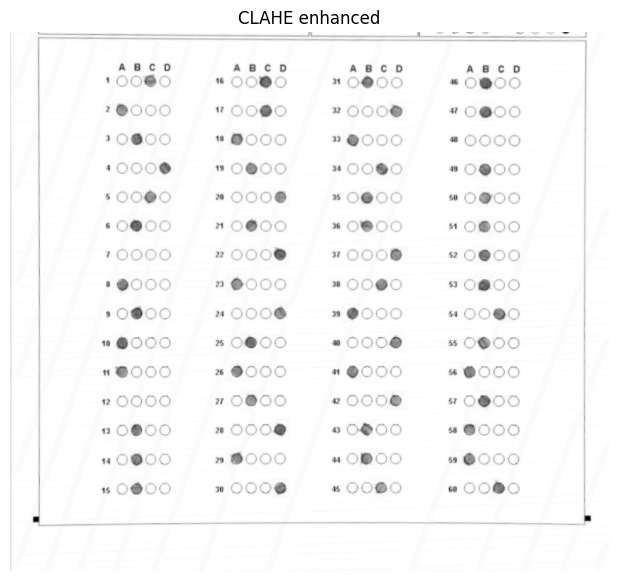

In [714]:
enhanced = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(norm)
show('CLAHE enhanced', enhanced, cmap='gray')

## 7) Adaptive threshold mask
This binary mask highlights ink-like areas and removes smooth background.
We use it to find the large ROI that contains the full bubble grid.
The parameters here control sensitivity to local contrast.

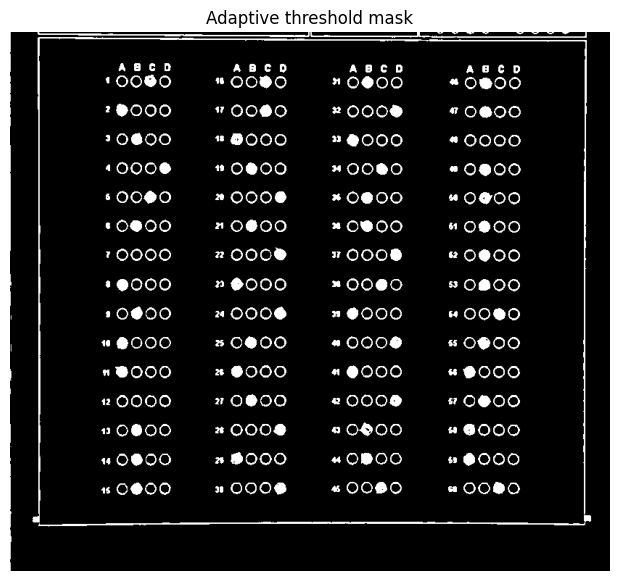

In [715]:
thresh_mask = cv2.adaptiveThreshold(
    enhanced, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 31, 9
)
show('Adaptive threshold mask', thresh_mask, cmap='gray')

## 8) Locate the answer section (ROI)
We scan large contours and count likely bubble circles within each candidate region.
The ROI is accepted only if it contains almost the full expected grid (>=236).
We also capture the matching portion of the threshold mask for later use.

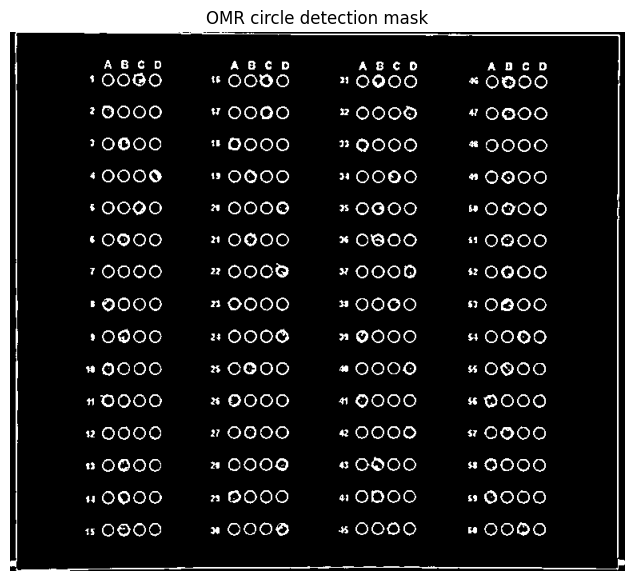

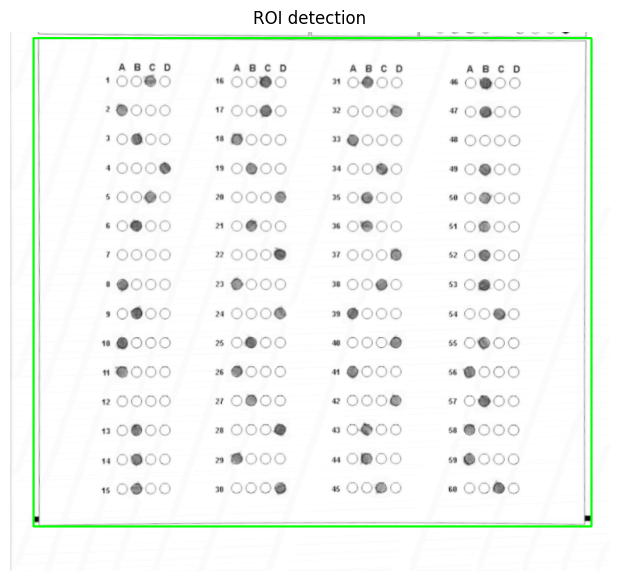

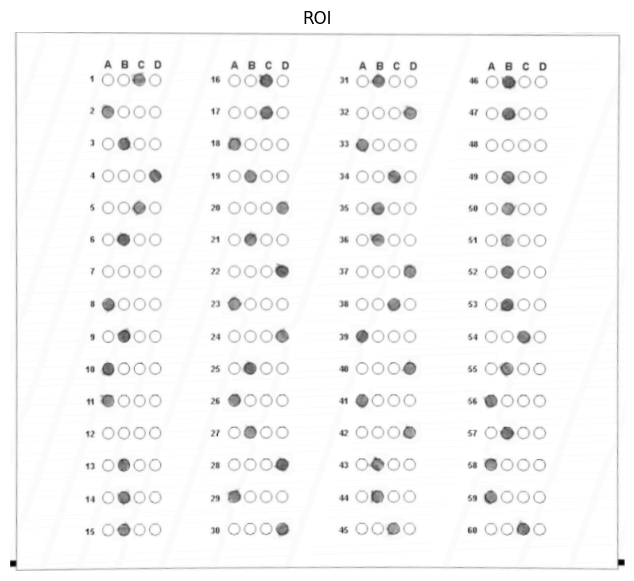

In [716]:
img_clean_bgr = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
cnts, _ = cv2.findContours(thresh_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def count_omr_circles(roi_img):
    gray = cv2.cvtColor(roi_img, cv2.COLOR_BGR2GRAY) if len(roi_img.shape) == 3 else roi_img.copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
    t = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                             cv2.THRESH_BINARY_INV, 11, 7)
    show('OMR circle detection mask', t, cmap='gray')
    cs = imutils.grab_contours(
        cv2.findContours(t.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    )
    return sum(1 for c in cs
               if 100 <= cv2.contourArea(c) <= 300
               and 0.5 <= cv2.boundingRect(c)[2] / float(cv2.boundingRect(c)[3]) <= 1.5)

roi = None
roi_box = None
masky = None
for cnt in cnts:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    x, y, w, h = cv2.boundingRect(approx)
    if w > 100 and h > 50:
        roi_temp = img_clean_bgr[y:y+h, x:x+w]
        masky_temp = thresh_mask[y:y+h, x:x+w]
        # print(f'Found contour at ({x}, {y}, {w}, {h}) with {count_omr_circles(roi_temp)} OMR circles')
        if count_omr_circles(roi_temp) >= 215:
            roi = roi_temp.copy()
            masky = masky_temp.copy()
            roi_box = (x, y, w, h)
            break

if roi is None:
    pass
    raise RuntimeError('Answer section not found.')

vis = img_clean_bgr.copy()
if roi_box:
    x, y, w, h = roi_box
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
show('ROI detection', vis)
show('ROI', roi)

## 9) Filter bubble contours in the ROI
We threshold the ROI again and filter contours by size and aspect ratio.
This step removes text, edges, and noise while keeping round bubble shapes.
The resulting contour count should be close to 240.

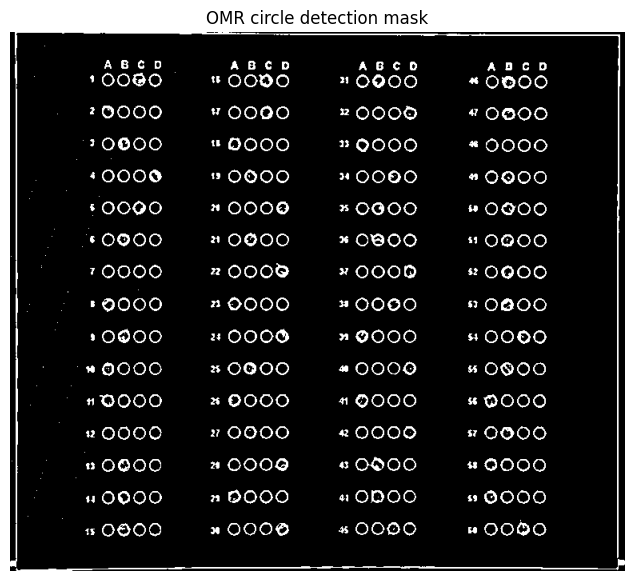

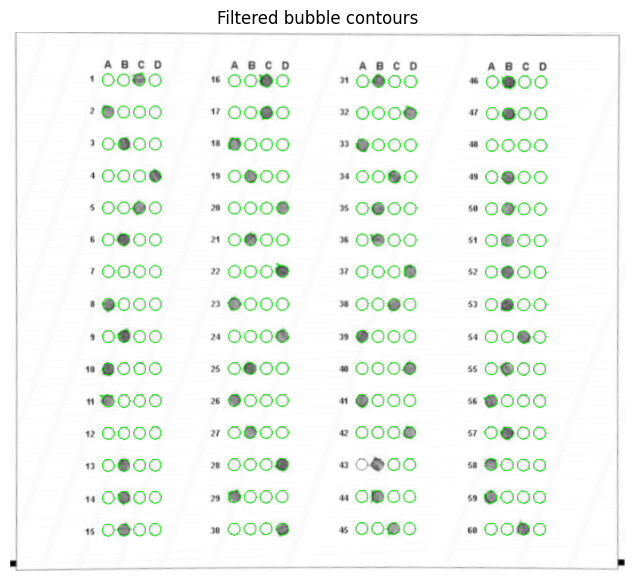

Filtered contours: 238


In [717]:
roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
closed = cv2.morphologyEx(roi_gray, cv2.MORPH_OPEN, kernel)
thresh_roi = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 5)
show('OMR circle detection mask', thresh_roi, cmap='gray')
all_bubble_cnts = imutils.grab_contours(
    cv2.findContours(thresh_roi.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
)
filtered_cnts = [
    c for c in all_bubble_cnts
    if 100 <= cv2.contourArea(c) <= 300
    and 0.5 <= cv2.boundingRect(c)[2] / float(cv2.boundingRect(c)[3]) <= 1.5
]

vis = roi.copy()
cv2.drawContours(vis, filtered_cnts, -1, (0, 255, 0), 1)
show('Filtered bubble contours', vis)
print('Filtered contours:', len(filtered_cnts))

## 10) Grid mapping
We map each bubble center into a 15x16 grid by clustering rows and columns.
Missing cells are filled using median box sizes and inferred positions.
The grid visualization should look like a clean lattice over the ROI.

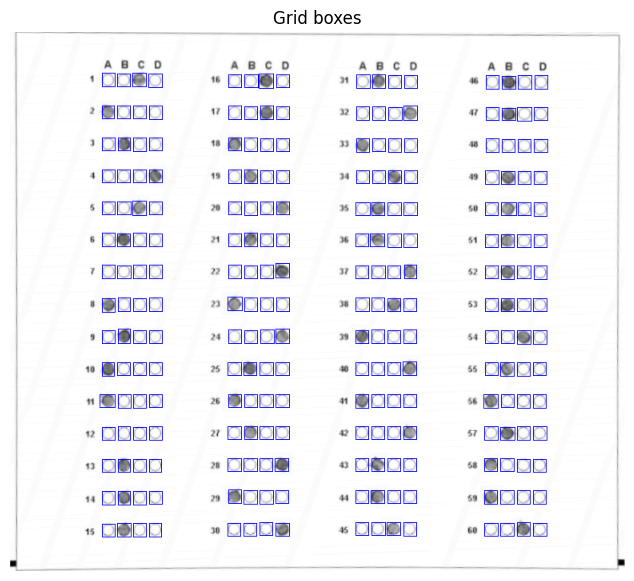

In [718]:
grid_boxes = build_grid(filtered_cnts)
if len(grid_boxes) != 240:
    raise RuntimeError(f'Expected 240 grid boxes, got {len(grid_boxes)}')

vis = roi.copy()
for box in grid_boxes:
    x, y, w, h = box['x'], box['y'], box['w'], box['h']
    cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 1)
show('Grid boxes', vis)

## 11) OMR map and bubble-only mask
We assign each grid cell to a (question, option) label and build a mask-only view.
Unlike V3, V4 keeps the binary mask from the ROI and copies only bubble regions.
This reduces background noise when detecting filled bubbles.

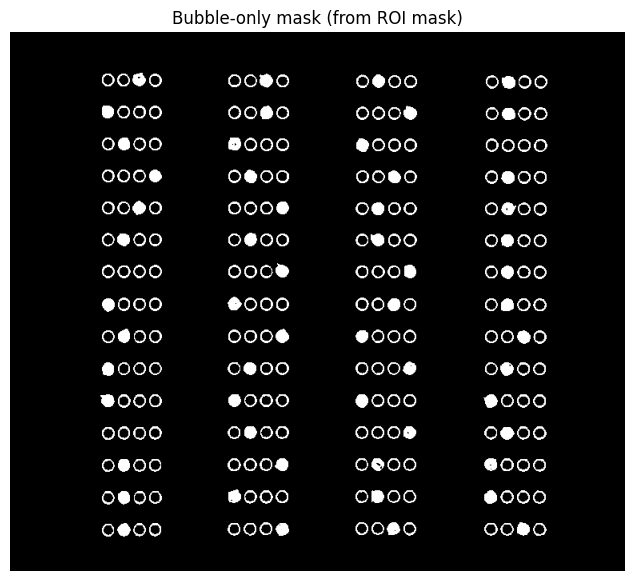

In [719]:
omr_map = {}
option_letters = ['A', 'B', 'C', 'D']
for row_idx in range(15):
    row_bubbles = grid_boxes[row_idx * 16:(row_idx + 1) * 16]
    for block_idx in range(4):
        q_num = block_idx * 15 + row_idx + 1
        options = row_bubbles[block_idx * 4:block_idx * 4 + 4]
        for opt_idx, bubble in enumerate(options):
            omr_map[f'{q_num}{option_letters[opt_idx]}'] = {
                'x': bubble['x'], 'y': bubble['y'], 'w': bubble['w'], 'h': bubble['h']
            }

bubble_only_masky = np.zeros_like(masky, dtype=masky.dtype)
for box in omr_map.values():
    x, y, w, h = box['x'], box['y'], box['w'], box['h']
    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(bubble_only_masky.shape[1], x + w), min(bubble_only_masky.shape[0], y + h)
    if x1 < x2 and y1 < y2:
        bubble_only_masky[y1:y2, x1:x2] = masky[y1:y2, x1:x2].copy()

show('Bubble-only mask (from ROI mask)', bubble_only_masky, cmap='gray')

## 12) Candidate bubbles from the mask
We find contours on the mask-only image, which should isolate bubble ink regions.
Filtering by size and aspect ratio removes thin marks and merged blobs.
The count should be close to the number of bubbles actually present.

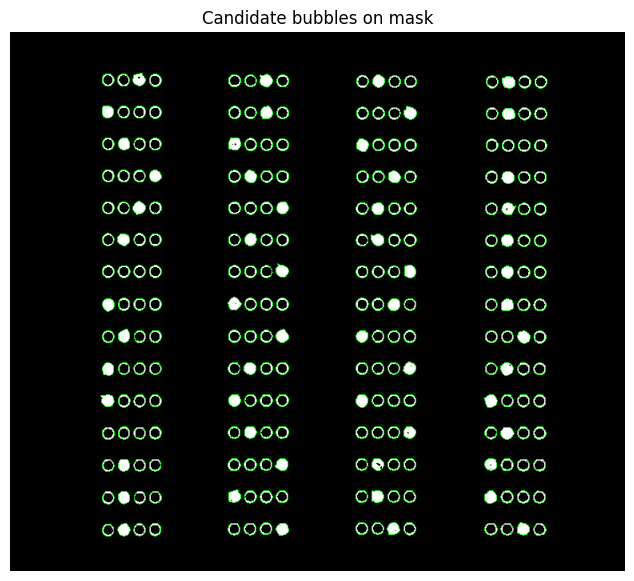

Candidate bubbles: 240


In [720]:
final_cnts = imutils.grab_contours(
    cv2.findContours(bubble_only_masky.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
)
candidate_bubbles = [
    c for c in final_cnts
    if cv2.boundingRect(c)[2] >= 12
    and cv2.boundingRect(c)[3] >= 12
    and 0.5 <= cv2.boundingRect(c)[2] / float(cv2.boundingRect(c)[3]) <= 1.5
]

vis = cv2.cvtColor(bubble_only_masky, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis, candidate_bubbles, -1, (0, 255, 0), 1)
show('Candidate bubbles on mask', vis)
print('Candidate bubbles:', len(candidate_bubbles))

## 13) Filled bubble detection and answers
We measure ink density inside each candidate bubble using pixel counts.
Each detected bubble is matched to the nearest label in the OMR map.
If multiple options are filled for one question, the output is 'MULTIPLE'.

Filled labels: ['1C', '2A', '3B', '4D', '5C', '6B', '8A', '9B', '10A', '11A', '13B', '14B', '15B', '16C', '17C', '18A', '19B', '20D', '21B', '22D', '23A', '24D', '25B', '26A', '27B', '28D', '29A', '30D', '31B', '32D', '33A', '34C', '35B', '36B', '37D', '38C', '39A', '40D', '41A', '42D', '43B', '44B', '45C', '46B', '47B', '49B', '50B', '51B', '52B', '53B', '54C', '55B', '56A', '57B', '58A', '59A', '60C']
Answer dict sample: {'q1': 'C', 'q2': 'A', 'q3': 'B', 'q4': 'D', 'q5': 'C', 'q6': 'B', 'q7': 'BLANK', 'q8': 'A', 'q9': 'B', 'q10': 'A'}
Accuracy: 100.00%


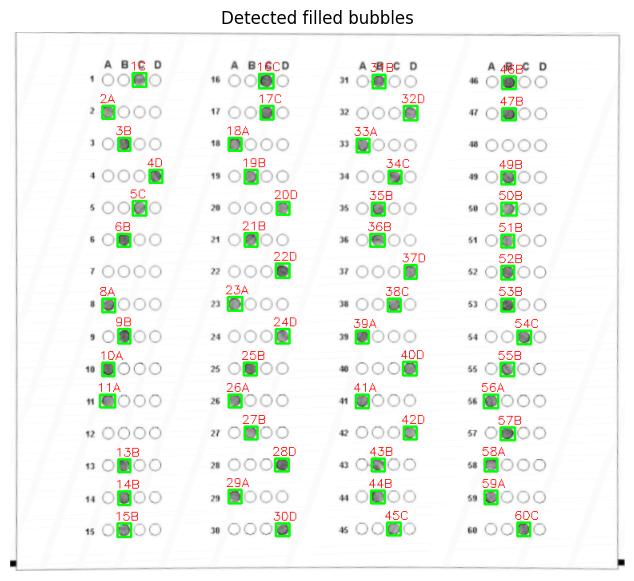

In [721]:
PIXEL_THRESHOLD = 150
filled_labels = []
vis = roi.copy()

for c in candidate_bubbles:
    x, y, w, h = cv2.boundingRect(c)
    cx, cy = x + w // 2, y + h // 2
    mask_c = np.zeros(bubble_only_masky.shape, dtype='uint8')
    cv2.drawContours(mask_c, [c], -1, 255, -1)
    masked = cv2.bitwise_and(bubble_only_masky, bubble_only_masky, mask=mask_c)
    total_px = cv2.countNonZero(masked)
    if total_px >= PIXEL_THRESHOLD:
        for label, box in omr_map.items():
            buf = 5
            if (box['x'] - buf <= cx <= box['x'] + box['w'] + buf and
                    box['y'] - buf <= cy <= box['y'] + box['h'] + buf):
                filled_labels.append(label)
                cv2.rectangle(vis, (box['x'], box['y']), (box['x'] + box['w'], box['y'] + box['h']), (0, 255, 0), 2)
                cv2.putText(vis, label, (box['x'] - 4, box['y'] - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
                break

filled_labels.sort(key=sort_key)
print('Filled labels:', filled_labels)

grouped = defaultdict(list)
for lbl in filled_labels:
    grouped[int(lbl[:-1])].append(lbl[-1])

answers_dict = {
    f'q{q}': 'BLANK' if not grouped[q] else (grouped[q][0] if len(grouped[q]) == 1 else 'MULTIPLE')
    for q in range(1, 61)
}
print('Answer dict sample:', dict(list(answers_dict.items())[:10]))

# Calculate accuracy if labels are available
# labels_df = pd.read_csv("../synthetic\\labels.csv")
labels_df = pd.read_csv(LABELS_CSV)
sample_id = int(re.search(r'synthetic_sample_(\d+)\.png', sample_path).group(1))

# Note: hardcoded row n is kept from the original script
true_answers = labels_df.iloc[IDX] 

accuracy = sum(1 for q in range(1, 61) if answers_dict[f'q{q}'] == true_answers[f'q{q}']) / 60.0
print(f'Accuracy: {accuracy:.2%}')
show('Detected filled bubbles', vis)